In [1]:
# Import required libraries
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
)
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import numpy as np
import pandas as pd

In [2]:
# Load the Maltese Semantic Analysis Dataset
dataset = load_dataset("DGurgurov/maltese_sa")
dataset

DatasetDict({
    train: Dataset({
        features: ['label', 'text'],
        num_rows: 595
    })
    validation: Dataset({
        features: ['label', 'text'],
        num_rows: 85
    })
    test: Dataset({
        features: ['label', 'text'],
        num_rows: 171
    })
})

In [3]:
dataset["train"][0]

{'label': 1,
 'text': "Nemmen li huwa baġit tajjeb, imma nies bħali ta' aktar minn 50 sena ma ssibx min jimpjegak, minkejja li l-gvern ta' inċentivi tajbin għal min iħaddimna."}

In [4]:
dataset["train"].features

{'label': Value('int64'), 'text': Value('string')}

In [5]:
sorted(set(dataset["train"]["label"]))

[0, 1]

In [6]:
# Checking the first 10 records of the training set to make sure dataset was loaded correctly
for i in range(10):
    print(dataset["train"][i])

{'label': 1, 'text': "Nemmen li huwa baġit tajjeb, imma nies bħali ta' aktar minn 50 sena ma ssibx min jimpjegak, minkejja li l-gvern ta' inċentivi tajbin għal min iħaddimna."}
{'label': 0, 'text': 'Nippremjaw lil min ilu jikser il-liġi snin u jaqla l-eluf minn propjeta mibnija illegalment, billi ntuh post aħjar.'}
{'label': 0, 'text': "Xi cuc irrid jitfacca b'kritika ta' din ix-xorta."}
{'label': 0, 'text': 'Ms. Metzola, ara jekk Ms. Mizzi jkollhiex ċans tagħtik ftit lezzjonijiet fuq kif għandek taġixxi biex ma tirredikolax ruħek u fl-istess ħin tagħmel xi ftit ġid kif suppost qegħda hemm biex tagħmel.'}
{'label': 1, 'text': 'Naf ċert li int qegħda hemm fejn il-Mulej tkompli tferraħ lil qrabatna li marru jiltaqgħu mal-Mulej ukoll.'}
{'label': 1, 'text': 'Ma nemminx li min ikun ser jikkommetti reati bħal dawn ikollu l-benedizzjoni mill-partit li jappoġġa.'}
{'label': 1, 'text': 'Sewwa jgħid il-Malti - Kelb rieqed la tqajmhux . Prosit Gonzi. Aħna warajk'}
{'label': 0, 'text': "Kull meta

In [7]:
# Load different datasets into Data Frame variables
train_df = pd.DataFrame(dataset["train"])
val_df = pd.DataFrame(dataset["validation"])
test_df = pd.DataFrame(dataset["test"])

print("Train label counts:")
print(train_df["label"].value_counts())

print("\nValidation label counts:")
print(val_df["label"].value_counts())

print("\nTest label counts:")
print(test_df["label"].value_counts())

Train label counts:
label
0    413
1    182
Name: count, dtype: int64

Validation label counts:
label
0    56
1    29
Name: count, dtype: int64

Test label counts:
label
0    111
1     60
Name: count, dtype: int64


In [8]:
# Load the tokenizer for the transformer model (BERTu)
model_name = "MLRS/BERTu"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2
)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: MLRS/BERTu
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
bert.pooler.dense.bias                     | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your do

In [9]:
# Convert raw text into tokens that the model can understand
def tokenize_function(batch):
    return tokenizer(batch["text"], truncation=True, max_length=128)

# Apply tokenization to the enter dataset
tokenized_dataset = dataset.map(tokenize_function, batched=True)
tokenized_dataset

DatasetDict({
    train: Dataset({
        features: ['label', 'text', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 595
    })
    validation: Dataset({
        features: ['label', 'text', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 85
    })
    test: Dataset({
        features: ['label', 'text', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 171
    })
})

In [10]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [11]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, predictions, average="binary", zero_division=0
    )
    accuracy = accuracy_score(labels, predictions)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }

In [12]:
from transformers import TrainingArguments, Trainer

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=100,
    weight_decay=0.01,
    logging_dir="./logs",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    disable_tqdm=True,  
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [13]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

In [14]:
trainer.train()

c:\Users\janfo\.conda\envs\MSC_Disseration\lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


{'eval_loss': '0.3014', 'eval_accuracy': '0.8824', 'eval_precision': '0.8519', 'eval_recall': '0.7931', 'eval_f1': '0.8214', 'eval_runtime': '3.156', 'eval_samples_per_second': '26.93', 'eval_steps_per_second': '1.901', 'epoch': '1'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

c:\Users\janfo\.conda\envs\MSC_Disseration\lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


{'eval_loss': '0.2549', 'eval_accuracy': '0.8824', 'eval_precision': '0.913', 'eval_recall': '0.7241', 'eval_f1': '0.8077', 'eval_runtime': '2.437', 'eval_samples_per_second': '34.88', 'eval_steps_per_second': '2.462', 'epoch': '2'}


...

c:\Users\janfo\.conda\envs\MSC_Disseration\lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


{'eval_loss': '0.7472', 'eval_accuracy': '0.8706', 'eval_precision': '0.75', 'eval_recall': '0.931', 'eval_f1': '0.8308', 'eval_runtime': '2.366', 'eval_samples_per_second': '35.93', 'eval_steps_per_second': '2.536', 'epoch': '11'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

c:\Users\janfo\.conda\envs\MSC_Disseration\lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


KeyboardInterrupt: 

In [ ]:
test_results = trainer.evaluate(tokenized_dataset["test"])
test_results

c:\Users\janfo\.conda\envs\MSC_Disseration\lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


{'eval_loss': '0.4995', 'eval_model_preparation_time': '0.004', 'eval_accuracy': '0.8889', 'eval_precision': '0.8727', 'eval_recall': '0.8', 'eval_f1': '0.8348', 'eval_runtime': '5.85', 'eval_samples_per_second': '29.23', 'eval_steps_per_second': '1.88', 'epoch': 0}


{'eval_loss': 0.499542236328125,
 'eval_model_preparation_time': 0.004,
 'eval_accuracy': 0.8888888888888888,
 'eval_precision': 0.8727272727272727,
 'eval_recall': 0.8,
 'eval_f1': 0.8347826086956521,
 'eval_runtime': 5.8502,
 'eval_samples_per_second': 29.23,
 'eval_steps_per_second': 1.88,
 'epoch': 0}

In [ ]:
trainer.save_model("./maltese_cyberbullying_model")
tokenizer.save_pretrained("./maltese_cyberbullying_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./maltese_cyberbullying_model\\tokenizer_config.json',
 './maltese_cyberbullying_model\\tokenizer.json')

In [ ]:
label_map = {
    0: "harmful",
    1: "non-harmful"
}

In [ ]:
def predict_text(text):
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )
    outputs = model(**inputs)
    prediction = int(outputs.logits.argmax(dim=-1).item())
    return label_map[prediction]

In [ ]:
examples = [
    "Prosit tassew għal dan ix-xogħol.",
    "Int ma tifhem xejn, vera stupidu.",
    "Mur lura fejn ġejt.",
    "Ma naqbilx miegħek imma nirrispettak."
]

for text in examples:
    print(text, "->", predict_text(text))

Prosit tassew għal dan ix-xogħol. -> non-harmful
Int ma tifhem xejn, vera stupidu. -> harmful
Mur lura fejn ġejt. -> harmful
Ma naqbilx miegħek imma nirrispettak. -> non-harmful


c:\Users\janfo\.conda\envs\MSC_Disseration\lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


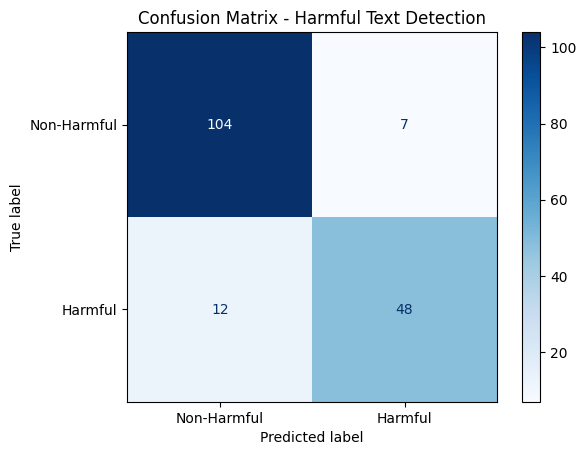

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Get predictions on the test set
predictions = trainer.predict(tokenized_dataset["test"])

y_true = predictions.label_ids
y_pred = np.argmax(predictions.predictions, axis=1)

# Create confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non-Harmful", "Harmful"])

disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Harmful Text Detection")
plt.show()

Using: C:\Users\janfo\Desktop\Thesis\Artefact\BERTu\results\checkpoint-300\trainer_state.json
Index(['epoch', 'grad_norm', 'learning_rate', 'loss', 'step', 'eval_accuracy',
       'eval_f1', 'eval_loss', 'eval_precision', 'eval_recall', 'eval_runtime',
       'eval_samples_per_second', 'eval_steps_per_second'],
      dtype='object')


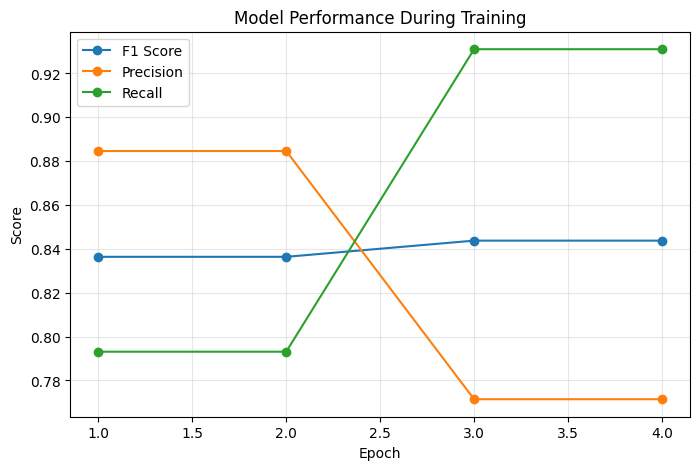

In [ ]:
import os
import json
import glob
import pandas as pd
import matplotlib.pyplot as plt

results_dir = r"C:\Users\janfo\Desktop\Thesis\Artefact\BERTu\results"

# Find trainer_state.json inside all checkpoint folders
state_files = glob.glob(os.path.join(results_dir, "checkpoint-*", "trainer_state.json"))

if not state_files:
    raise FileNotFoundError("No trainer_state.json found inside checkpoint folders.")

# Sort checkpoints by checkpoint number instead of modified time
state_files = sorted(
    state_files,
    key=lambda x: int(os.path.basename(os.path.dirname(x)).split("-")[-1])
)

latest_state_file = state_files[-1]

print("Using:", latest_state_file)

with open(latest_state_file, "r", encoding="utf-8") as f:
    trainer_state = json.load(f)

logs = trainer_state["log_history"]
df = pd.DataFrame(logs)

print(df.columns)

# Keep only rows with evaluation metrics
eval_df = df.dropna(subset=["eval_f1", "eval_precision", "eval_recall", "epoch"]).copy()

plt.figure(figsize=(8, 5))
plt.plot(eval_df["epoch"], eval_df["eval_f1"], marker="o", label="F1 Score")
plt.plot(eval_df["epoch"], eval_df["eval_precision"], marker="o", label="Precision")
plt.plot(eval_df["epoch"], eval_df["eval_recall"], marker="o", label="Recall")

plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Model Performance During Training")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()